# 微调

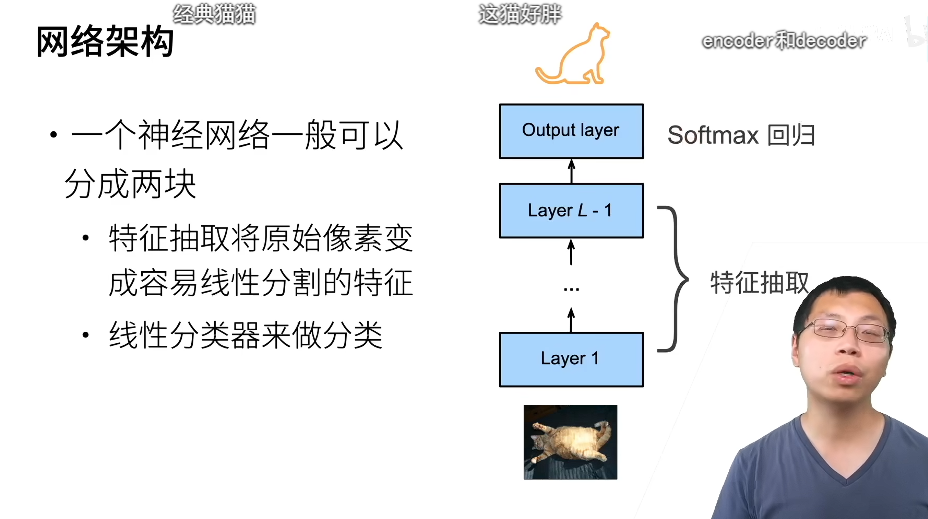

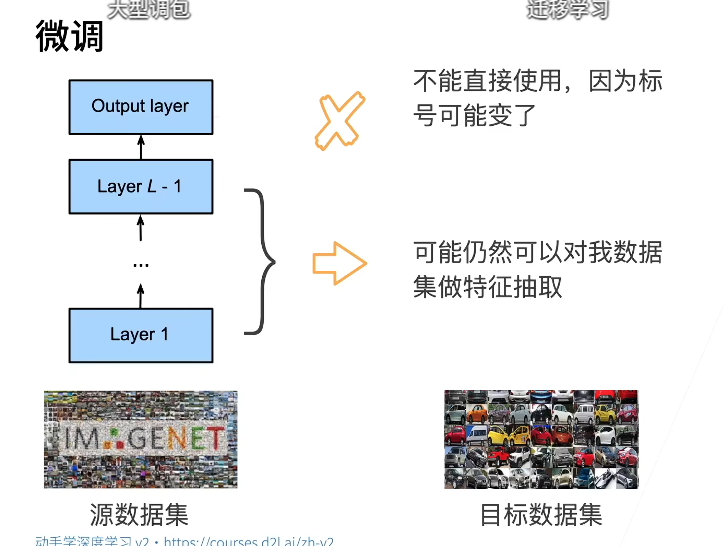

ImageNet（尤其是 ILSVRC 2012 数据集，即 ImageNet-1K）是计算机视觉领域最成熟、最经典的预训练数据集，堪称“视觉界的通用语”，预训练出的权重（如 ResNet、VGG 中的卷积核）成为了极高质量的通用特征提取器。

在源数据集上做的模型的特征提取部分可能仍然可以用在我的数据集上

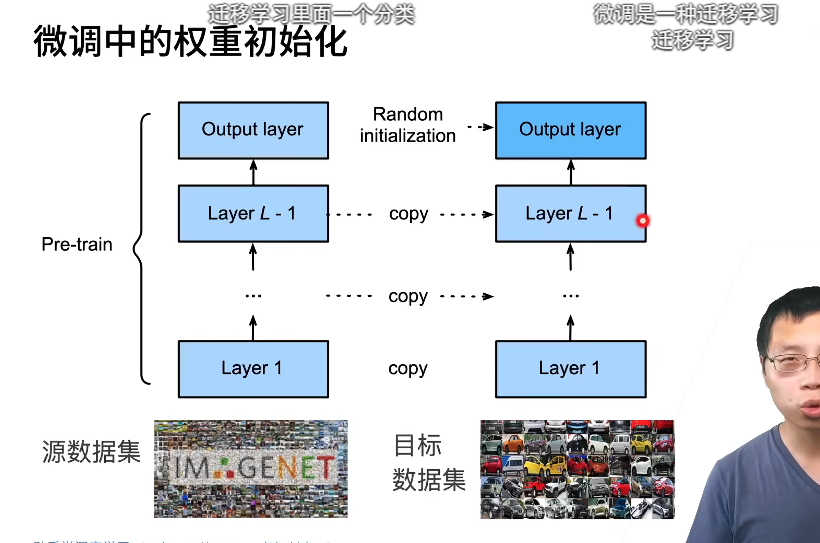

模型初始化使用之前在源数据集上预训练的模型

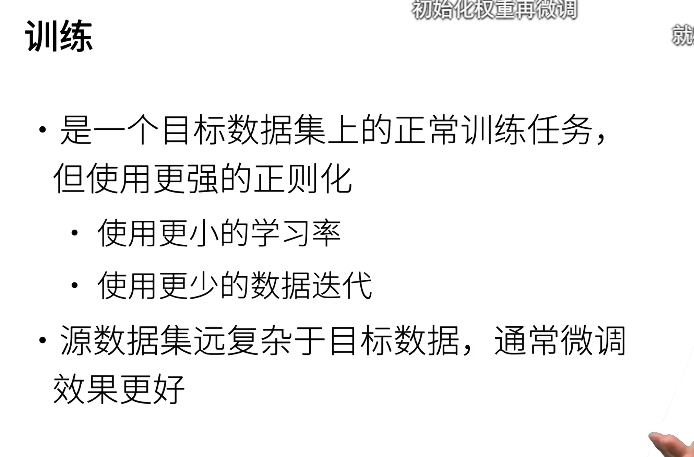

使用预训练的模型参数后只需微调，所以使用更小的学习率和数据更迭

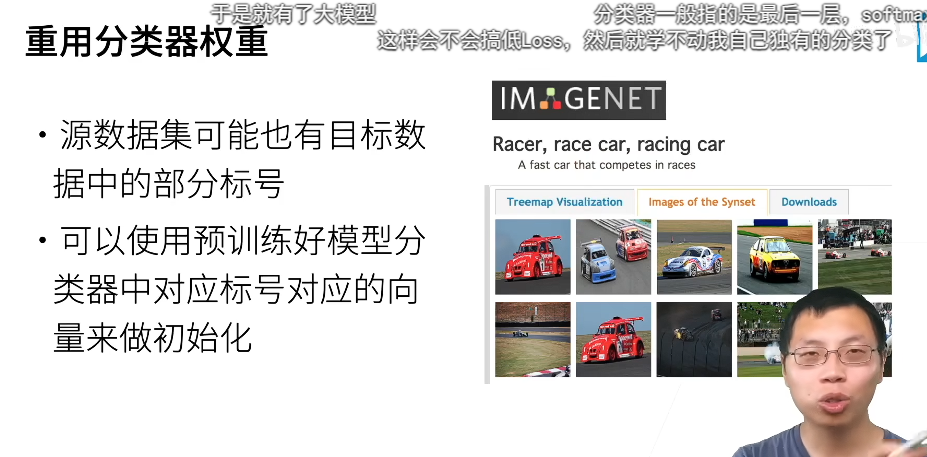

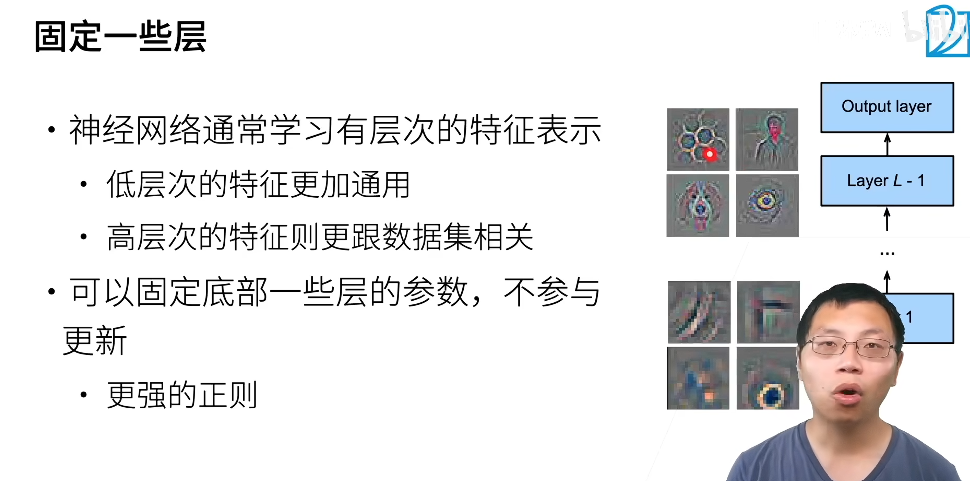

底层特征更加通用，所以可以固定底层参数不变

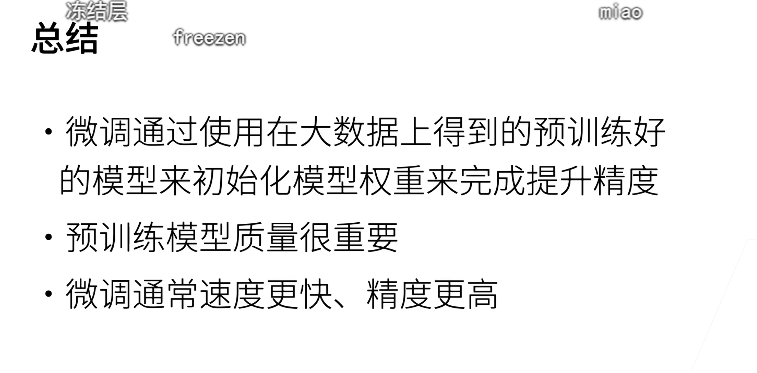

微调（Fine-tuning）是迁移学习（Transfer Learning）的一种核心实现方式

迁移学习（父集）：是一种宏观思想。它指将模型在“源任务”（如海量通用数据）上学到的知识，迁移应用到“目标任务”（如特定细分领域）上。只要利用了之前的经验，都算迁移学习。

微调（子集）：是一种具体操作。它指在预训练模型的基础上，用目标任务的数据继续训练，并更新模型的全部或部分权重参数。

## 代码

https://zh-v2.d2l.ai/chapter_computer-vision/fine-tuning.html#id3

In [1]:
%matplotlib inline
import os
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

没下载数据集，不运行

In [ ]:
#@save
d2l.DATA_HUB['hotdog'] = (d2l.DATA_URL + 'hotdog.zip','fba480ffa8aa7e0febbb511d181409f899b9baa5')
data_dir = d2l.download_extract('hotdog')

In [ ]:
train_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'))
test_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'))

In [ ]:
hotdogs = [train_imgs[i][0] for i in range(8)]
not_hotdogs = [train_imgs[-i - 1][0] for i in range(8)]
d2l.show_images(hotdogs + not_hotdogs, 2, 8, scale=1.4);

数据增广

# 使⽤RGB通道的均值和标准差，以标准化每个通道
normalize = torchvision.transforms.Normalize(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    normalize])

test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize])

定义和初始化模型

In [ ]:
pretrained_net = torchvision.models.resnet18(pretrained=True)    #把预训练参数保留

In [ ]:
pretrained_net.fc   #全连接层

In [ ]:
Linear(in_features=512, out_features=1000, bias=True)

In [ ]:
finetune_net = torchvision.models.resnet18(pretrained=True)
finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 2)
nn.init.xavier_uniform_(finetune_net.fc.weight)

In [ ]:
# 如果param_group=True，输出层中的模型参数将使用十倍的学习率
def train_fine_tuning(net, learning_rate, batch_size=128, num_epochs=5,
                      param_group=True):
    train_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'train'), transform=train_augs),
        batch_size=batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'test'), transform=test_augs),
        batch_size=batch_size)
    devices = d2l.try_all_gpus()
    loss = nn.CrossEntropyLoss(reduction="none")
    
    if param_group:   #如果是True，除了最后一层的所有参数
        params_1x = [param for name, param in net.named_parameters()
             if name not in ["fc.weight", "fc.bias"]]
        trainer = torch.optim.SGD([{'params': params_1x},
                                   {'params': net.fc.parameters(),
                                    'lr': learning_rate * 10}],
                                lr=learning_rate, weight_decay=0.001)
    else:
        trainer = torch.optim.SGD(net.parameters(), lr=learning_rate,
                                  weight_decay=0.001)
    d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
                   devices)

In [ ]:
train_fine_tuning(finetune_net, 5e-5)

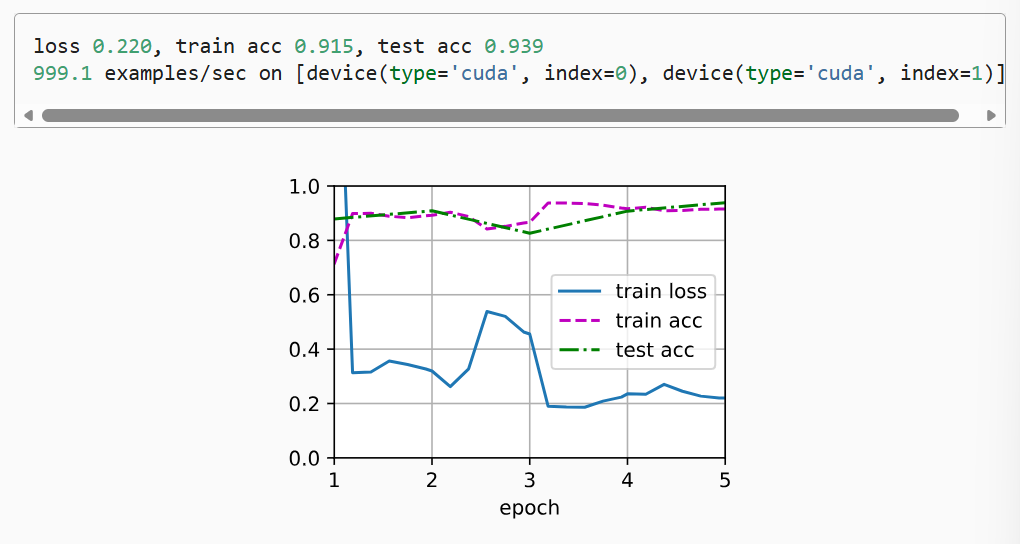

比较：所有模型参数初始化为随机值

In [ ]:
scratch_net = torchvision.models.resnet18()
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 2)
train_fine_tuning(scratch_net, 5e-4, param_group=False)

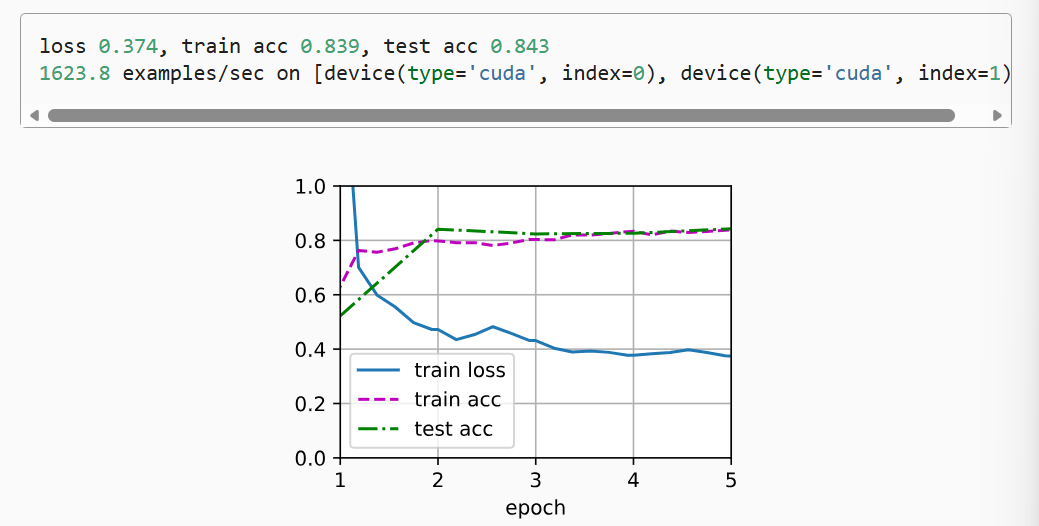

微调模型往往表现更好，因为它的初始参数值更有效。